This page aims to experiment whether the initialization method would result differently under the high dimensional, low warmup condition.  
In this experiment we will use Gaussian Misture Model and Multivariate Normal distribution, while only vary the dimensionality and warmup length.

**Package Setup and functions**

In [1]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

# remember to restart runtime after changing the environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 623.2/623.2 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 34.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0

In [1]:
import numpy as np
# from matplotlib.pyplot import *

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from inference_gym import using_jax as gym
tfb = tfp.bijectors

from tensorflow_probability.substrates import numpy as tfp_np
tfd_np = tfp_np.distributions

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

import warnings
warnings.filterwarnings('ignore')

import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

from google.colab import drive
drive.mount('/content/drive')

[CudaDevice(id=0)]
gpu
Mounted at /content/drive


In [2]:
# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

def kernel_setup(warmup_length, naive):
  num_warmup_short, num_sampling_short = warmup_length, 1
  total_samples_short = num_warmup_short + num_sampling_short

  kernel_short = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn, init_step_size, 1)
  kernel_short = tfp.experimental.mcmc.GradientBasedTrajectoryLengthAdaptation(kernel_short, num_warmup_short)
  kernel_short = tfp.mcmc.DualAveragingStepSizeAdaptation(
      kernel_short, num_warmup_short, target_accept_prob = 0.75,  #0.75,
      reduce_fn = tfp.math.reduce_log_harmonic_mean_exp)

  if (naive):
    # initialize each chain at a different location
    initial_state = initialize((num_chains_short,))

  else:
    # Chains within a super chain are all initialized at the same location
    initial_state = initialize((num_super_chains,))
    initial_state = np.repeat(initial_state, num_chains_short // num_super_chains,
                            axis = 0)
  return kernel_short, initial_state, total_samples_short

def _reduce_variance_interval(x, axis=None, biased=True, keepdims=False):
    # ddof=0 is biased variance (N), ddof=1 is unbiased variance (N-1)
    ddof = 0 if biased else 1
    return jnp.var(x, axis=axis, ddof=ddof, keepdims=keepdims)


def nested_rhat_constrained(result_state, num_super_chains,idx):
    # since we use only N=1, W_k is reduced to 0

    num_sub_chains = result_state.shape[0] // num_super_chains
    num_dimensions = result_state.shape[1]

    chain_states = result_state.reshape(1, -1, num_sub_chains, num_dimensions)
    # chain_states.shape = (1,16,128,2)
    # f_bar 1*k is:
    mean_subchain = jnp.mean(chain_states, axis=2)
    # mean_subchain.shape =(1,16,2)

    # f_bar **K is:
    mean_superchain = jnp.mean(mean_subchain, axis=1)
    # mean_superchain.shape = (1,2)

    variance_chain = _reduce_variance_interval(chain_states, axis=2, biased=False)
    # print(variance_chain.shape) # (1,16,2)
    W = jnp.mean(variance_chain, axis=1)
    # print(f"W dim: {W.shape}") # (1,2)
    B = _reduce_variance_interval(mean_subchain, axis=1, biased=False) # variance of between super chain

    r_hat = jnp.sqrt(1+B/W)[:,idx]
    return r_hat

In [9]:
def simulation(keys,length, naive, repitition, MSE_list, R_Hat_list, num_dim):
  kernel_short, initial_state, total_samples_short = kernel_setup(length,naive)
  result_mse = []
  for sim in range(repitition):
    # print(f"{sim}-th round:")
    result_short = tfp.mcmc.sample_chain(
        total_samples_short, initial_state, kernel = kernel_short,
        seed =keys[sim], trace_fn=None)[-1,:,:]
    # print(f"result_short shape: {result_short.shape}")

    # the f bar
    estimate = result_short.mean(axis=0)
    error = estimate - mean_est
    se = error**2
    # following the formula from paper, there is a factor = KM/var
    # but when doing KM/var, the MSE jumps to 10^3
    factor = 1/var_est
    mse = (factor * se).mean()
    result_mse.append(mse)

    record = {
        "Warmup Length": length,
        "MSE":mse,
        "Number of Dimensions": num_dim
    }

    for dim in range(num_dim):
      new_r_hat = nested_rhat_constrained(result_short, num_super_chains, dim)
      record[f"r_hat_{dim}"] = new_r_hat[-1]
    R_Hat_list.append(record)
    del record
    del result_short
    gc.collect()

  # calculation time:
  result_mse = np.array(result_mse)
  result_mse_best = result_mse.min(axis=0)
  result_mse_worst = result_mse.max(axis=0)
  estimate_mse = result_mse.mean(axis=0)

  MSE_list.append({"Warmup Length":length,
                   "Number of Dimension": num_dim,
                   "Avg MSE": estimate_mse,
                   "Best MSE": result_mse_best,
                   "Worst MSE": result_mse_worst})
  if naive:
    print(f"Naive initialization. Warmup Length: {length}; mean of MSE is: {estimate_mse}")
  else:
    print(f"Constrained initialization. Warmup Length: {length}; mean of MSE is: {estimate_mse}")
  del kernel_short
  del initial_state
  del total_samples_short
  del result_mse
  gc.collect()
  jax.clear_caches()

In [13]:
def MSE_vs_distance(constrained_df, naive_df, title):
  fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
  common = dict(
    logx=True,
    logy=True,
    legend=False,
    ax=ax,
    ylabel="MSE",
    x="Warmup Length"
    )
  ax = constrained_df.plot(
    y="Avg MSE",
    title=title,
    linestyle="-",
    color="orange",
    **common
  )
  constrained_df.plot(
    y="Best MSE",
    linestyle="--",
    color="orange",
    **common
    )
  constrained_df.plot(
    y="Worst MSE",
    linestyle="--",
    color="orange",
    **common)
  naive_df.plot(
    y="Avg MSE",
    linestyle="-",
    color="black",
    **common)
  naive_df.plot(
    y="Worst MSE",
    linestyle="--",
    color="black",
    **common)
  naive_df.plot(
    y="Best MSE",
    linestyle="--",
    color="black",
    **common)
  ax.legend(handles=[
    Line2D([0], [0], color="orange", lw=2, label="Constrained"),
    Line2D([0], [0], color="black", lw=2, label="Naive")])

In [5]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def MSE_vs_Rhat(df, title, naive):
    df_copy = deepcopy(df)

    # Shift all R-hat columns by 1
    rhat_cols = [c for c in df_copy.columns if c.startswith("r_hat_")]
    df_copy[rhat_cols] = df_copy[rhat_cols] - 1

    fig, ax = plt.subplots(figsize=(10,8), dpi=150)

    # Plot every R-hat dimension
    sc = None
    for i, col in enumerate(rhat_cols):
        sc = ax.scatter(
            df_copy[col],
            df_copy["MSE"],
            c=df_copy["Warmup Length"],
            cmap="viridis",
            # take this out to get a not log scale color
            norm=LogNorm(vmin=df_copy["Warmup Length"].min(),
                 vmax=df_copy["Warmup Length"].max()),
            s=20,          # marker size
            alpha=0.5      # transparency
        )

    # Axis scales
    ax.set_yscale("log")
    if not naive:
        ax.set_xscale("log")

    # Reference lines
    ax.axhline(y=chi_up / num_chains_short,
               color="black", linestyle="--")
    ax.axhline(y=chi_lo / num_chains_short,
               color="black", linestyle="--")
    ax.axhline(y=1 / num_chains_short,
               color="black")
    ax.axvline(x=eps_lower,
               color="blue", linestyle="--")

    # Labels and title
    ax.set_xlabel(r"$\widehat{R}_{\nu} - 1$")
    ax.set_ylabel("MSE")
    ax.set_title(title)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Mean")

    plt.tight_layout()
    plt.show()

## MVN Section

**Tuning Param Setup**

In [6]:
dimRange = [50,80,100,200,500]
warmup_length = [10,25,50,75,100]

**Kernel Setup**

In [7]:
rho = .5
def MVN_builder(num_dim):
  # mean array:
  mu = [float(5) for i in range(num_dim)]
  # covariance matrix:
  cov = [ [rho**(abs(i-j)) for j in range(num_dim)] for i in range(num_dim)]
  target = tfd.MultivariateNormalFullCovariance(
      loc=jnp.array(mu),
      covariance_matrix=jnp.array(cov))

  init_step_size = 0.5
  def target_log_prob_fn(x):
    return target.log_prob(x)
  def initialize(shape, key=random.PRNGKey(123)):
    return random.normal(key, shape + (num_dim,))

  return target, init_step_size, target_log_prob_fn, initialize

**Simulation Phase**

In [8]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []

In [10]:
for dim in dimRange:
  mem(f"Simulation start")
  print(f"-------------------------Dimension: {dim}------------------------")
  target, init_step_size, target_log_prob_fn, initialize = MVN_builder(dim)
  mean_est = target.mean()
  var_est = 1
  for length in warmup_length:
    print(f"-------------Warmup Length: {length}-----------------")
    simulation(keys,length,
               naive=False, repitition = repitition,
               MSE_list=MSE_constrained_list, R_Hat_list=R_Hat_constrained_list,
               num_dim=dim)
    simulation(keys,length,
               naive=True, repitition = repitition,
               MSE_list=MSE_naive_list, R_Hat_list=R_Hat_naive_list,
               num_dim=dim)


MSE_constrained_df = pd.DataFrame(MSE_constrained_list)
MSE_naive_df = pd.DataFrame(MSE_naive_list)

R_Hat_constrained_df = pd.DataFrame(R_Hat_constrained_list)
R_Hat_naive_df = pd.DataFrame(R_Hat_naive_list)

Simulation start: 1367.5 MB
Dimension: 50
Warmup Length: 10
Constrained initialization. Warmup Length: 10; mean of MSE is: 12.053552627563477
Naive initialization. Warmup Length: 10; mean of MSE is: 12.044360160827637
Warmup Length: 25
Constrained initialization. Warmup Length: 25; mean of MSE is: 2.978480100631714
Naive initialization. Warmup Length: 25; mean of MSE is: 2.8388941287994385
Warmup Length: 50
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.027531975880265236
Naive initialization. Warmup Length: 50; mean of MSE is: 0.03482490032911301
Warmup Length: 75
Constrained initialization. Warmup Length: 75; mean of MSE is: 0.0004601151740644127
Naive initialization. Warmup Length: 75; mean of MSE is: 0.0004810762475244701
Warmup Length: 100
Constrained initialization. Warmup Length: 100; mean of MSE is: 0.00046147764078341424
Naive initialization. Warmup Length: 100; mean of MSE is: 0.0004457369796000421
Simulation start: 1869.7 MB
Dimension: 80
Warmup Length: 10


Side note: I tried to crank the rho up to one and that did not give me a good time. As soon as the warmup length gets to 50 the solver seemed to be stopped there.

In [11]:
MSE_constrained_df.head()

,Warmup Length,Number of Dimension,Avg MSE,Best MSE,Worst MSE
0,10,50,12.053553,10.933508,13.393290
1,25,50,2.978480,2.042033,4.382768
2,50,50,0.027532,0.018690,0.046679
3,75,50,0.000460,0.000322,0.000644
4,100,50,0.000461,0.000318,0.000601


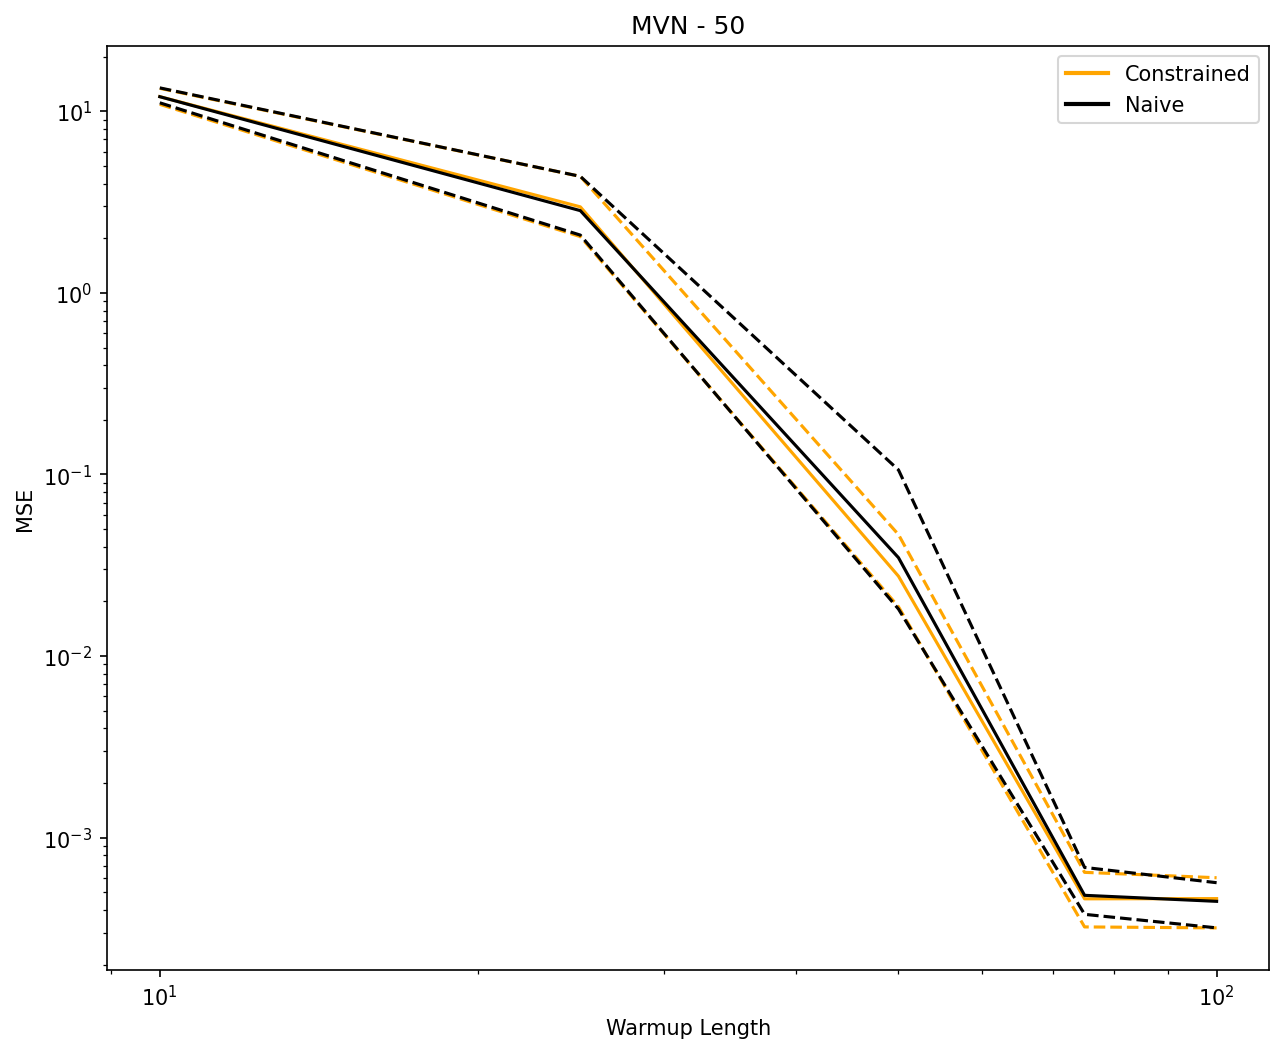

In [15]:
MSE_vs_distance(MSE_constrained_df[MSE_constrained_df['Number of Dimension']==50],MSE_naive_df[MSE_naive_df['Number of Dimension']==50],"MVN - 50")

In [16]:
MSE_constrained_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_MSE_constrained.pkl"
)

MSE_naive_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_MSE_naive.pkl"
)

R_Hat_constrained_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_R_Hat_constrained.pkl"
)

R_Hat_naive_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/MVN_R_Hat_naive.pkl"
)

## GMM section

**Kernel Setup**

In [19]:
def GMM_builder(num_dim):
  dist = tfd.MixtureSameFamily(
    mixture_distribution=tfd.Categorical(probs=[0.3, 0.7]),
    components_distribution=tfd.MultivariateNormalDiag(
      loc=[jnp.repeat(-5., num_dim), jnp.repeat(5., num_dim)],
      scale_diag=jnp.repeat(1., num_dim)))

  def target_log_prob_fn(x):
    return dist.log_prob(x)

  offset = 0
  def initialize (shape, key = random.PRNGKey(37272709)):
    return 10 * random.normal(key, shape + (num_dim,)) + offset

  mean_est = jnp.repeat(2, num_dim)
  var_est = jnp.repeat(22, num_dim)

  init_step_size = 1
  return dist, init_step_size, target_log_prob_fn, initialize, mean_est, var_est

**Sampling Phase**

In [20]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []

In [21]:
for dim in dimRange:
  mem(f"Simulation start")
  print(f"-------------------------Dimension: {dim}------------------------")
  target, init_step_size, target_log_prob_fn, initialize, mean_est,var_est = GMM_builder(dim)

  for length in warmup_length:
    simulation(keys,length,
               naive=False, repitition = repitition,
               MSE_list=MSE_constrained_list, R_Hat_list=R_Hat_constrained_list,
               num_dim=dim)
    simulation(keys,length,
               naive=True, repitition = repitition,
               MSE_list=MSE_naive_list, R_Hat_list=R_Hat_naive_list,
               num_dim=dim)


MSE_constrained_df = pd.DataFrame(MSE_constrained_list)
MSE_naive_df = pd.DataFrame(MSE_naive_list)

R_Hat_constrained_df = pd.DataFrame(R_Hat_constrained_list)
R_Hat_naive_df = pd.DataFrame(R_Hat_naive_list)

Simulation start: 2575.1 MB
-------------------------Dimension: 50------------------------
-------------Warmup Length: 10-----------------
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.1821340024471283
Naive initialization. Warmup Length: 10; mean of MSE is: 0.1929108202457428
-------------Warmup Length: 25-----------------
Constrained initialization. Warmup Length: 25; mean of MSE is: 0.18187548220157623
Naive initialization. Warmup Length: 25; mean of MSE is: 0.19277605414390564
-------------Warmup Length: 50-----------------
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.18173253536224365
Naive initialization. Warmup Length: 50; mean of MSE is: 0.1927272081375122
-------------Warmup Length: 75-----------------
Constrained initialization. Warmup Length: 75; mean of MSE is: 0.1817423552274704
Naive initialization. Warmup Length: 75; mean of MSE is: 0.19272705912590027
-------------Warmup Length: 100-----------------
Constrained initialization. Warm

In [22]:
MSE_constrained_df.head()

,Warmup Length,Number of Dimension,Avg MSE,Best MSE,Worst MSE
0,10,50,0.182134,0.181352,0.183335
1,25,50,0.181875,0.180611,0.183106
2,50,50,0.181733,0.180826,0.182838
3,75,50,0.181742,0.181209,0.182711
4,100,50,0.181705,0.180506,0.182517


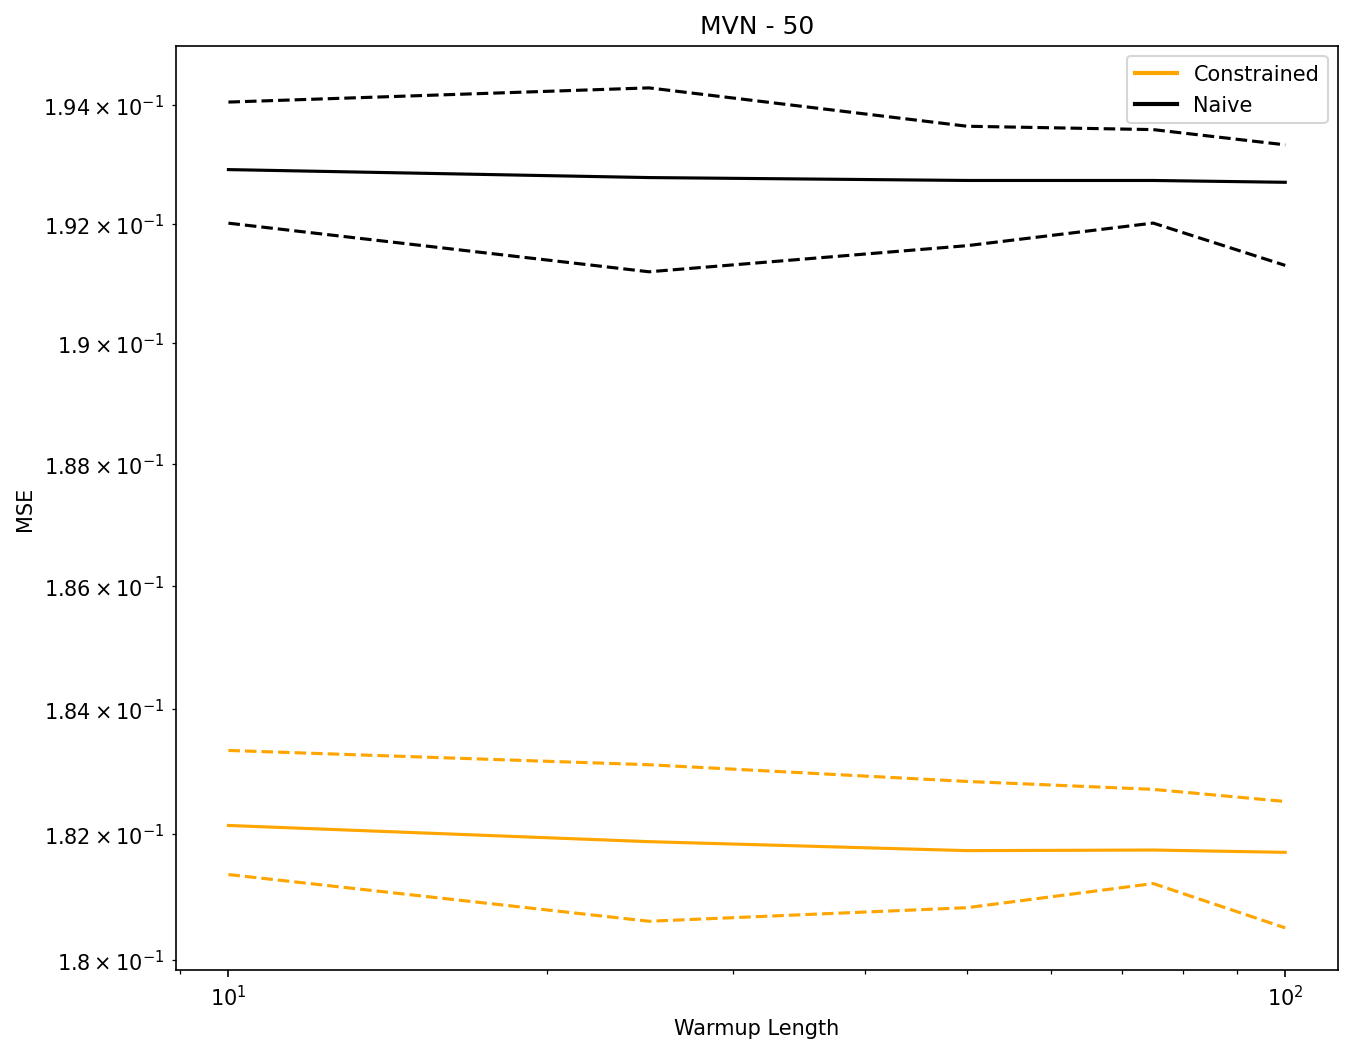

In [23]:
MSE_vs_distance(MSE_constrained_df[MSE_constrained_df['Number of Dimension']==50],MSE_naive_df[MSE_naive_df['Number of Dimension']==50],"MVN - 50")

In [24]:
MSE_constrained_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_MSE_constrained.pkl"
)

MSE_naive_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_MSE_naive.pkl"
)

R_Hat_constrained_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_R_Hat_constrained.pkl"
)

R_Hat_naive_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/GMM_R_Hat_naive.pkl"
)